<a href="https://colab.research.google.com/github/dariakadina/satprak/blob/main/EDA_LAST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EDA проекта: Student Performance Dataset

**Тема проекта:** анализ факторов, связанных с итоговой успеваемостью студентов.

**Датасет:** UCI Student Performance Dataset. В датасете представлены данные о студентах двух португальских школ: демографические признаки, семейные и школьные характеристики, учебные привычки, социальные факторы, пропуски и оценки за три периода.

В датасете есть две таблицы:

- `student-mat.csv` — успеваемость по математике;
- `student-por.csv` — успеваемость по португальскому языку.

**Главная переменная для анализа:** `G3` — итоговая оценка за курс по шкале от 0 до 20.



## 1.


In [3]:
import os
import zipfile
import urllib.request
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:.3f}")

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

## 2. Загрузка данных



In [4]:

  import pandas as pd

mat = pd.read_csv("student-mat.csv", sep=";")
por = pd.read_csv("student-por.csv", sep=";")

mat["subject"] = "math"
por["subject"] = "portuguese"

df = pd.concat([mat, por], ignore_index=True)

df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,traveltime,studytime,failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3,subject
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,course,mother,2,2,0,yes,no,no,no,yes,yes,no,no,4,3,4,1,1,3,6,5,6,6,math
1,GP,F,17,U,GT3,T,1,1,at_home,other,course,father,1,2,0,no,yes,no,no,no,yes,yes,no,5,3,3,1,1,3,4,5,5,6,math
2,GP,F,15,U,LE3,T,1,1,at_home,other,other,mother,1,2,3,yes,no,yes,no,yes,yes,yes,no,4,3,2,2,3,3,10,7,8,10,math
3,GP,F,15,U,GT3,T,4,2,health,services,home,mother,1,3,0,no,yes,yes,yes,yes,yes,yes,yes,3,2,2,1,1,5,2,15,14,15,math
4,GP,F,16,U,GT3,T,3,3,other,other,home,father,1,2,0,no,yes,yes,no,yes,yes,no,no,4,3,2,1,2,5,4,6,10,10,math


## 3. Описание признаков


- **демография:** `school`, `sex`, `age`, `address`;
- **семья:** `famsize`, `Pstatus`, `Medu`, `Fedu`, `Mjob`, `Fjob`, `guardian`, `famrel`, `famsup`;
- **учебные условия и поведение:** `studytime`, `failures`, `schoolsup`, `paid`, `activities`, `nursery`, `higher`, `internet`, `absences`;
- **социальные привычки и образ жизни:** `romantic`, `freetime`, `goout`, `Dalc`, `Walc`, `health`;
- **оценки:** `G1`, `G2`, `G3`;
- **предмет:** `subject`.

In [5]:
feature_description = pd.DataFrame({
    "feature": [
        "school", "sex", "age", "address", "famsize", "Pstatus", "Medu", "Fedu",
        "Mjob", "Fjob", "reason", "guardian", "traveltime", "studytime", "failures",
        "schoolsup", "famsup", "paid", "activities", "nursery", "higher", "internet",
        "romantic", "famrel", "freetime", "goout", "Dalc", "Walc", "health",
        "absences", "G1", "G2", "G3", "subject"
    ],
    "description": [
        "школа студента", "пол", "возраст", "тип адреса: город/село", "размер семьи", "статус совместного проживания родителей",
        "образование матери", "образование отца", "работа матери", "работа отца", "причина выбора школы", "опекун",
        "время в пути до школы", "время учебы в неделю", "число прошлых академических неудач", "дополнительная школьная поддержка",
        "семейная образовательная поддержка", "платные дополнительные занятия", "внеучебные активности", "посещение детского сада",
        "планирует получить высшее образование", "доступ к интернету дома", "романтические отношения", "качество семейных отношений",
        "свободное время", "время с друзьями", "употребление алкоголя в будни", "употребление алкоголя в выходные", "состояние здоровья",
        "число пропусков", "оценка за 1-й период", "оценка за 2-й период", "итоговая оценка", "предмет"
    ]
})

feature_description

,feature,description
0,school,школа студента
1,sex,пол
2,age,возраст
3,address,тип адреса: город/село
4,famsize,размер семьи
5,Pstatus,статус совместного проживания родителей
6,Medu,образование матери
7,Fedu,образование отца
8,Mjob,работа матери
9,Fjob,работа отца


## 4. Общий обзор структуры данных


In [6]:
print("Размер объединенного датасета:", df.shape)
print("Количество строк:", df.shape[0])
print("Количество столбцов:", df.shape[1])

df.info()

Размер объединенного датасета: (1044, 34)
Количество строк: 1044
Количество столбцов: 34
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1044 entries, 0 to 1043
Data columns (total 34 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      1044 non-null   object
 1   sex         1044 non-null   object
 2   age         1044 non-null   int64 
 3   address     1044 non-null   object
 4   famsize     1044 non-null   object
 5   Pstatus     1044 non-null   object
 6   Medu        1044 non-null   int64 
 7   Fedu        1044 non-null   int64 
 8   Mjob        1044 non-null   object
 9   Fjob        1044 non-null   object
 10  reason      1044 non-null   object
 11  guardian    1044 non-null   object
 12  traveltime  1044 non-null   int64 
 13  studytime   1044 non-null   int64 
 14  failures    1044 non-null   int64 
 15  schoolsup   1044 non-null   object
 16  famsup      1044 non-null   object
 17  paid        1044 non-null   object
 18 

In [7]:
summary_table = pd.DataFrame({
    "dtype": df.dtypes,
    "n_unique": df.nunique(),
    "missing_count": df.isna().sum(),
    "missing_share": df.isna().mean()
}).sort_values("missing_count", ascending=False)

summary_table

,dtype,n_unique,missing_count,missing_share
school,object,2,0,0.000
sex,object,2,0,0.000
age,int64,8,0,0.000
address,object,2,0,0.000
famsize,object,2,0,0.000
Pstatus,object,2,0,0.000
Medu,int64,5,0,0.000
Fedu,int64,5,0,0.000
Mjob,object,5,0,0.000
Fjob,object,5,0,0.000


In [8]:
print("Количество полных дубликатов:", df.duplicated().sum())
print("Количество дубликатов без учета subject:", df.drop(columns="subject").duplicated().sum())

Количество полных дубликатов: 0
Количество дубликатов без учета subject: 0


### Вывод по качеству данных

в датасете нет пропущенных значений

## 5. Базовая описательная статистика

Посмотрим описательную статистику по числовым признакам. Особое внимание уделяется оценкам `G1`, `G2`, `G3`, числу пропусков `absences`, времени на учебу `studytime`, прошлым неудачам `failures` и социальным признакам.

In [9]:
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()

print("Числовые признаки:", numeric_cols)
print("Категориальные признаки:", categorical_cols)

df[numeric_cols].describe().T

Числовые признаки: ['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'G3']
Категориальные признаки: ['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'subject']


,count,mean,std,min,25%,50%,75%,max
age,1044.000,16.726,1.240,15.000,16.000,17.000,18.000,22.000
Medu,1044.000,2.603,1.125,0.000,2.000,3.000,4.000,4.000
Fedu,1044.000,2.388,1.100,0.000,1.000,2.000,3.000,4.000
traveltime,1044.000,1.523,0.732,1.000,1.000,1.000,2.000,4.000
studytime,1044.000,1.970,0.834,1.000,1.000,2.000,2.000,4.000
failures,1044.000,0.264,0.656,0.000,0.000,0.000,0.000,3.000
famrel,1044.000,3.936,0.933,1.000,4.000,4.000,5.000,5.000
freetime,1044.000,3.201,1.032,1.000,3.000,3.000,4.000,5.000
goout,1044.000,3.156,1.153,1.000,2.000,3.000,4.000,5.000
Dalc,1044.000,1.494,0.912,1.000,1.000,1.000,2.000,5.000


In [10]:
# Описательная статистика отдельно по предметам
subject_desc = df.groupby("subject")[["G1", "G2", "G3", "absences", "studytime", "failures"]].agg([
    "count", "mean", "median", "std", "min", "max"
])

subject_desc

G1                                G2                          \
           count   mean median   std min max count   mean median   std min   
subject                                                                      
math         395 10.909 11.000 3.319   3  19   395 10.714 11.000 3.762   0   
portuguese   649 11.399 11.000 2.745   0  19   649 11.570 11.000 2.914   0   

                  G3                             absences                     \
           max count   mean median   std min max    count  mean median   std   
subject                                                                        
math        19   395 10.415 11.000 4.581   0  20      395 5.709  4.000 8.003   
portuguese  19   649 11.906 12.000 3.231   0  19      649 3.659  2.000 4.641   

                   studytime                            failures               \
           min max     count  mean median   std min max    count  mean median   
subject                                                                         
math         0  75       395 2.035  2.000 0.839   1   4      395 0.334  0.000   
portuguese   0  32       649 1.931  2.000 0.830   1   4      649 0.222  0.000   

                          
             std min max  
subject                   
math       0.744   0   3  
portuguese 0.593   0   3

## 6. Распределение целевой переменной `G3`

`G3` — итоговая оценка за курс. Это ключевая переменная, которую далее можно использовать как целевую переменную в задаче регрессии.

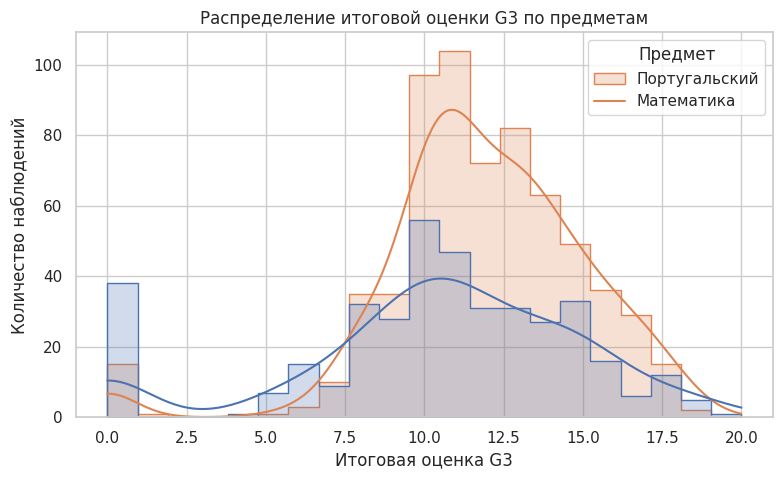

In [11]:
plt.figure(figsize=(9, 5))
sns.histplot(data=df, x="G3", hue="subject", bins=21, kde=True, element="step")
plt.title("Распределение итоговой оценки G3 по предметам")
plt.xlabel("Итоговая оценка G3")
plt.ylabel("Количество наблюдений")
plt.legend(title="Предмет", labels=["Португальский", "Математика"])
plt.show()

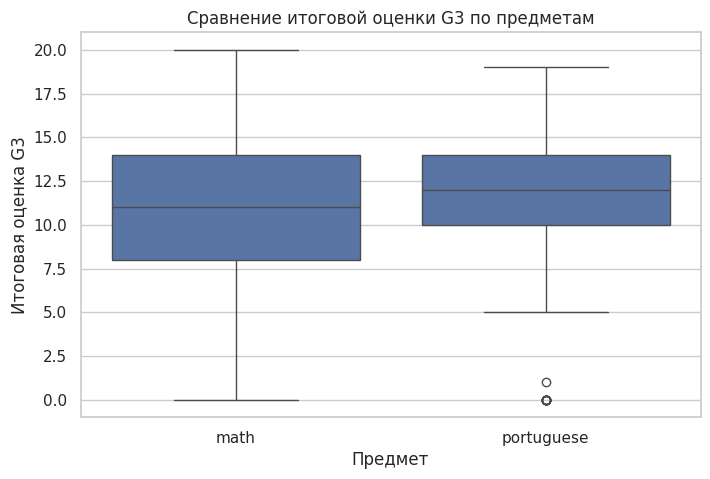

In [12]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="subject", y="G3")
plt.title("Сравнение итоговой оценки G3 по предметам")
plt.xlabel("Предмет")
plt.ylabel("Итоговая оценка G3")
plt.show()

In [13]:
g3_by_subject = df.groupby("subject")["G3"].agg(["count", "mean", "median", "std", "min", "max"])
g3_by_subject

,count,mean,median,std,min,max
subject,,,,,,
math,395,10.415,11.000,4.581,0,20
portuguese,649,11.906,12.000,3.231,0,19


In [14]:
for subj, row in g3_by_subject.iterrows():
    print(
        f"Предмет: {subj}. Средняя итоговая оценка G3 = {row['mean']:.2f}, "
        f"медиана = {row['median']:.2f}, стандартное отклонение = {row['std']:.2f}."
    )

best_subject = g3_by_subject["mean"].idxmax()
print(f"\nПо среднему значению G3 выше результат у предмета: {best_subject}.")

Предмет: math. Средняя итоговая оценка G3 = 10.42, медиана = 11.00, стандартное отклонение = 4.58.
Предмет: portuguese. Средняя итоговая оценка G3 = 11.91, медиана = 12.00, стандартное отклонение = 3.23.

По среднему значению G3 выше результат у предмета: portuguese.


## 7. Динамика оценок: `G1`, `G2`, `G3`

Оценки `G1`, `G2`, `G3` соответствуют 1-му, 2-му и итоговому периоду. Логично ожидать, что они сильно связаны между собой.

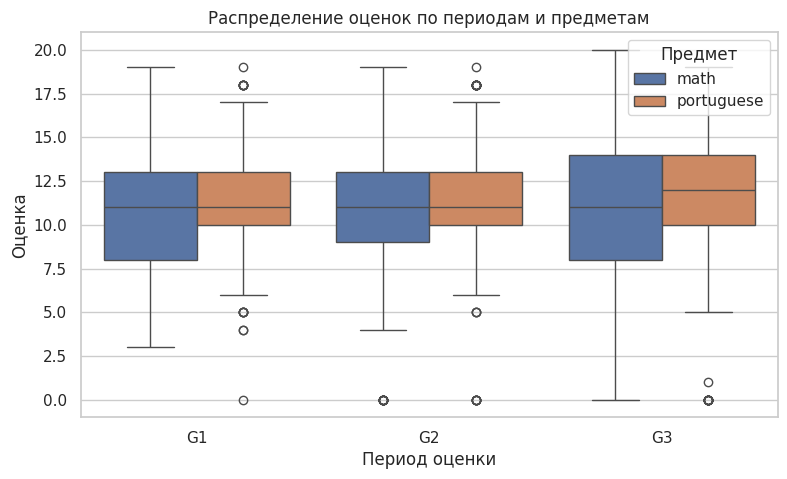

In [15]:
grades_long = df.melt(
    id_vars=["subject"],
    value_vars=["G1", "G2", "G3"],
    var_name="period",
    value_name="grade"
)

plt.figure(figsize=(9, 5))
sns.boxplot(data=grades_long, x="period", y="grade", hue="subject")
plt.title("Распределение оценок по периодам и предметам")
plt.xlabel("Период оценки")
plt.ylabel("Оценка")
plt.legend(title="Предмет")
plt.show()

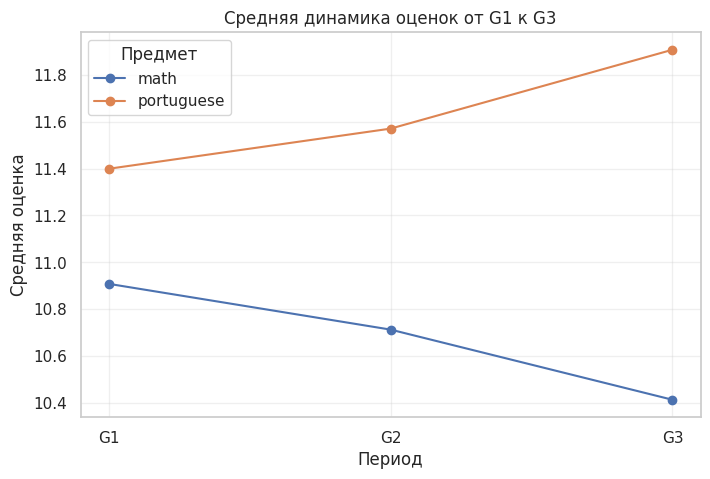

,G1,G2,G3
subject,,,
math,10.909,10.714,10.415
portuguese,11.399,11.570,11.906


In [16]:
mean_grades = df.groupby("subject")[["G1", "G2", "G3"]].mean()

plt.figure(figsize=(8, 5))
for subj in mean_grades.index:
    plt.plot(["G1", "G2", "G3"], mean_grades.loc[subj], marker="o", label=subj)

plt.title("Средняя динамика оценок от G1 к G3")
plt.xlabel("Период")
plt.ylabel("Средняя оценка")
plt.legend(title="Предмет")
plt.grid(alpha=0.3)
plt.show()

mean_grades

## 8. Корреляционный анализ числовых признаков

Корреляционная матрица показывает линейные связи между числовыми переменными. Для дальнейшего моделирования особенно важны связи `G3` с `G1`, `G2`, `failures`, `studytime`, `absences` и поведенческими признаками.

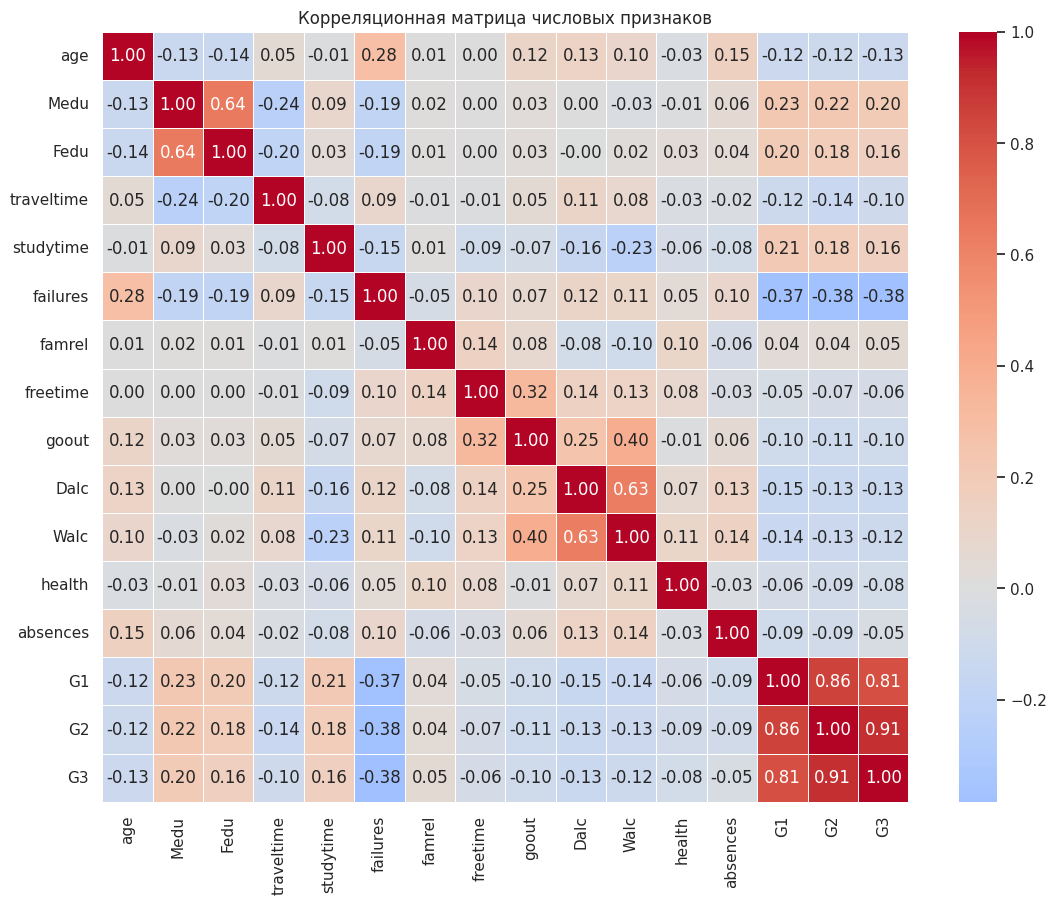

In [17]:
corr = df[numeric_cols].corr()

plt.figure(figsize=(13, 10))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, linewidths=0.5)
plt.title("Корреляционная матрица числовых признаков")
plt.show()

In [18]:
g3_corr = corr["G3"].drop("G3").sort_values(key=lambda x: x.abs(), ascending=False)

g3_corr_df = g3_corr.reset_index()
g3_corr_df.columns = ["feature", "corr_with_G3"]
g3_corr_df

,feature,corr_with_G3
0,G2,0.911
1,G1,0.809
2,failures,-0.383
3,Medu,0.201
4,studytime,0.162
5,Fedu,0.160
6,Dalc,-0.130
7,age,-0.125
8,Walc,-0.116
9,traveltime,-0.103


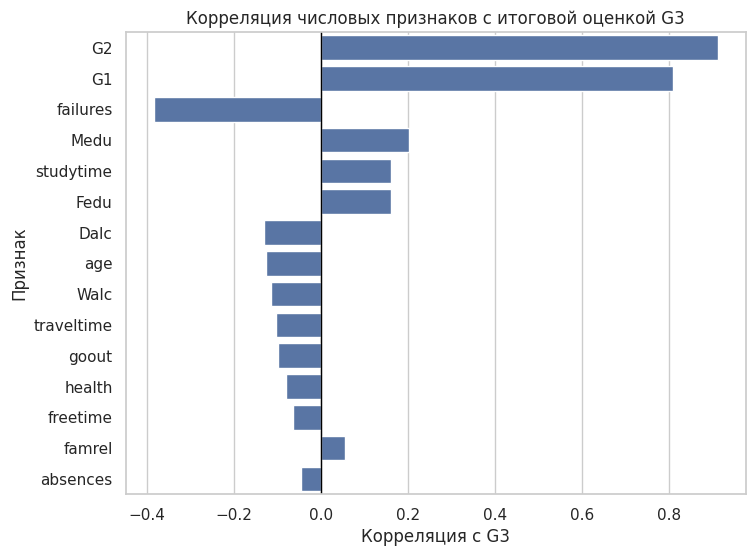

In [19]:
plt.figure(figsize=(8, 6))
sns.barplot(data=g3_corr_df, x="corr_with_G3", y="feature")
plt.title("Корреляция числовых признаков с итоговой оценкой G3")
plt.xlabel("Корреляция с G3")
plt.ylabel("Признак")
plt.axvline(0, color="black", linewidth=1)
plt.show()

### Вывод по корреляциям

Ожидаемо, наиболее сильная связь с итоговой оценкой `G3` обычно наблюдается у `G2` и `G1`: предыдущие оценки отражают текущий академический уровень студента. Также полезно смотреть на `failures`, `studytime`, `absences`, `goout`, `Dalc`, `Walc`, так как они отражают учебную историю и поведенческие факторы.

## 9. Анализ категориальных признаков

Посмотрим распределения категориальных переменных и сравним среднее значение `G3` по группам.

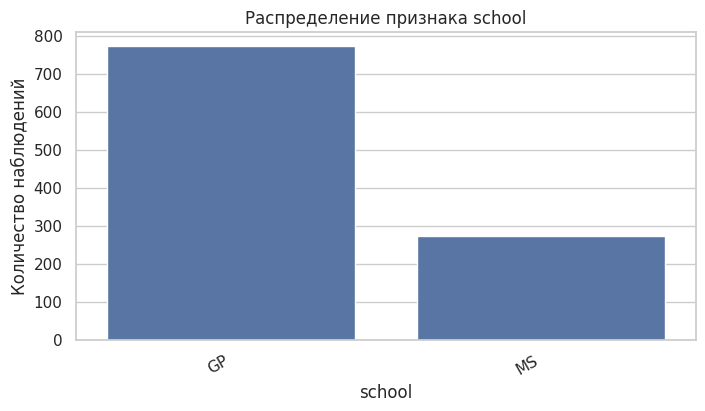

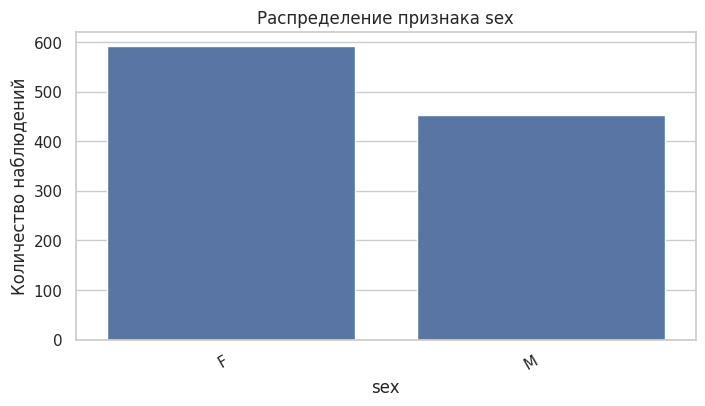

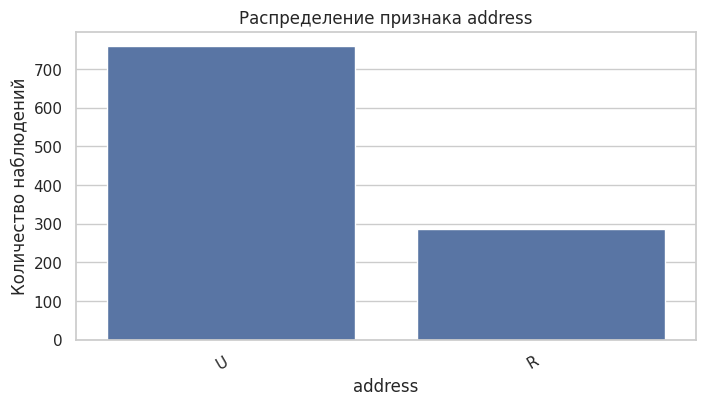

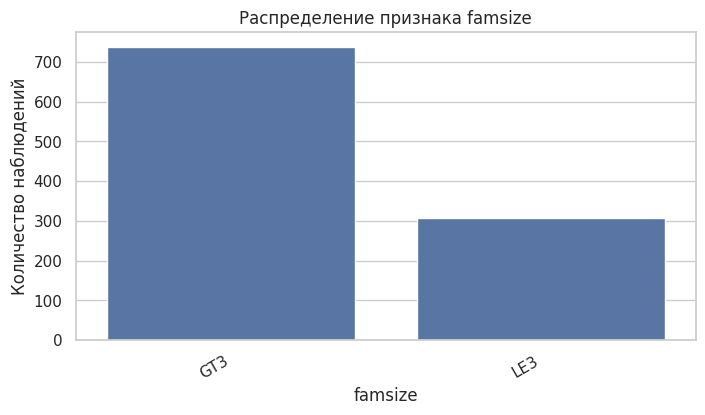

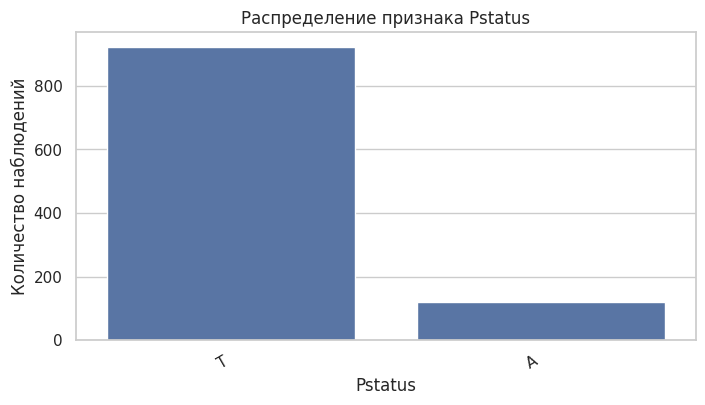

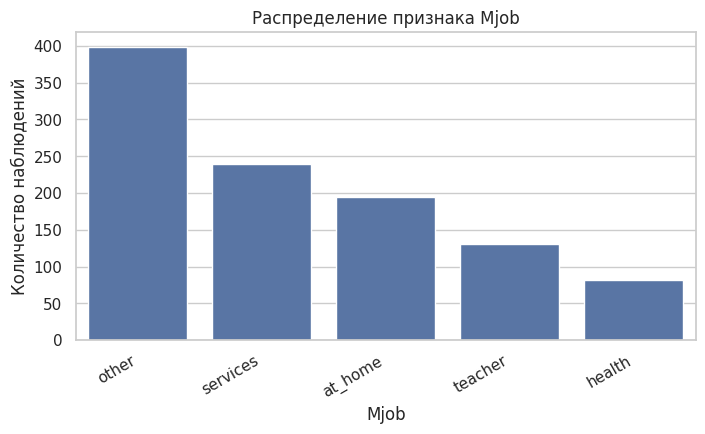

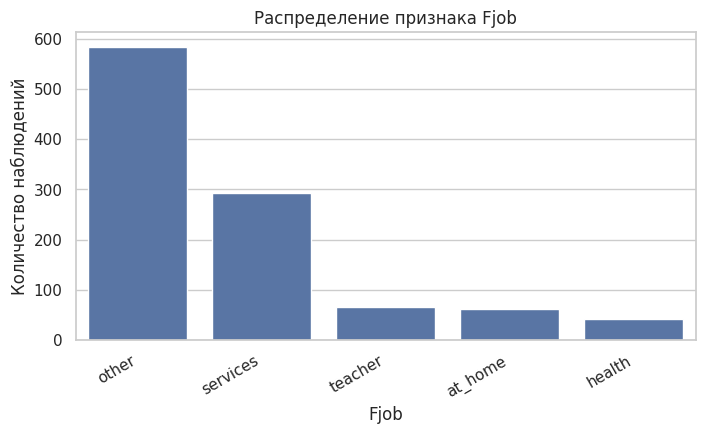

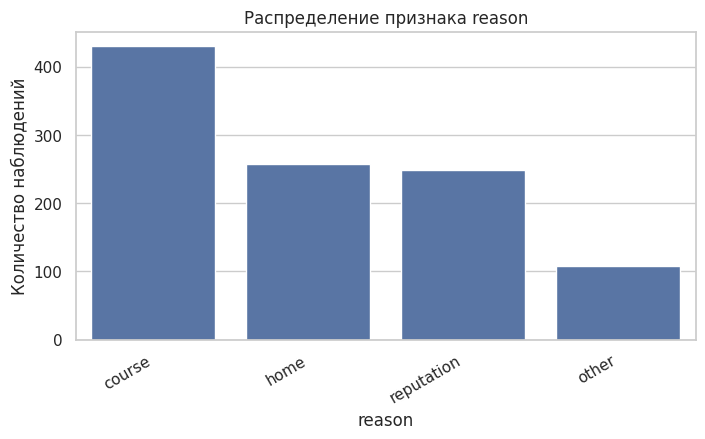

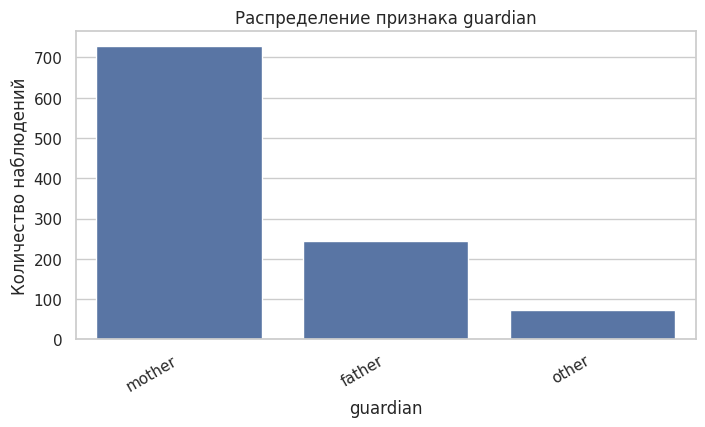

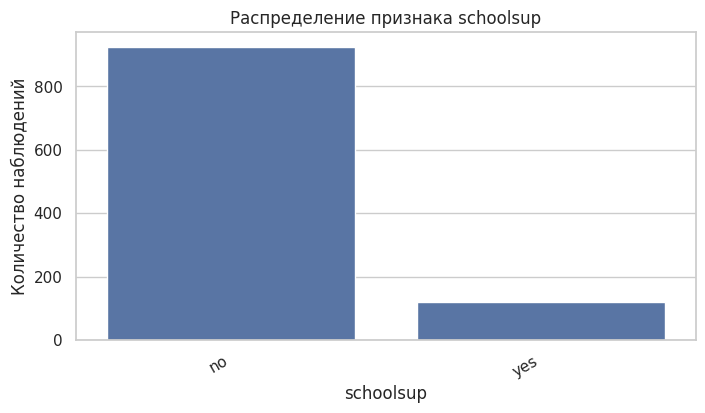

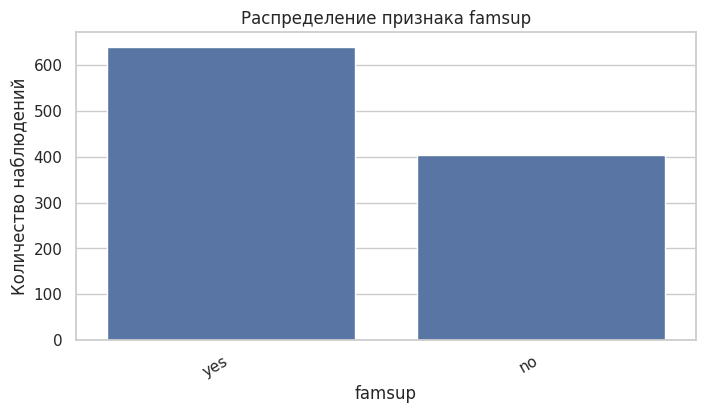

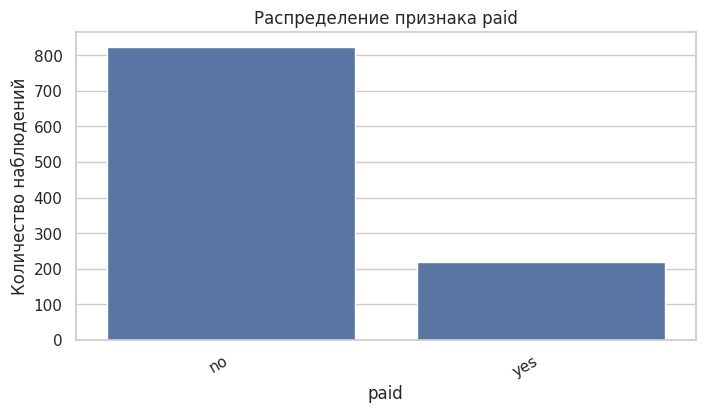

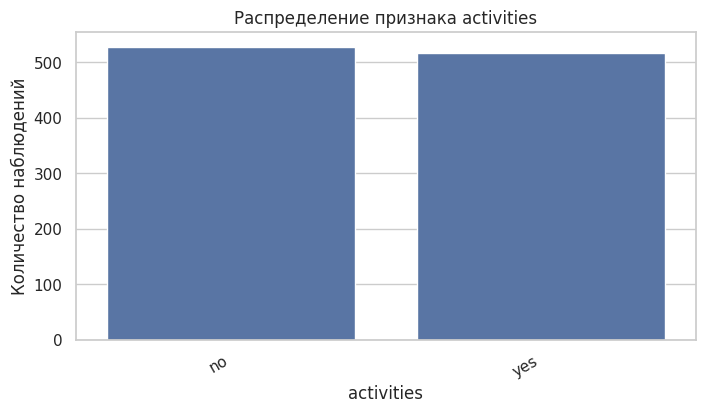

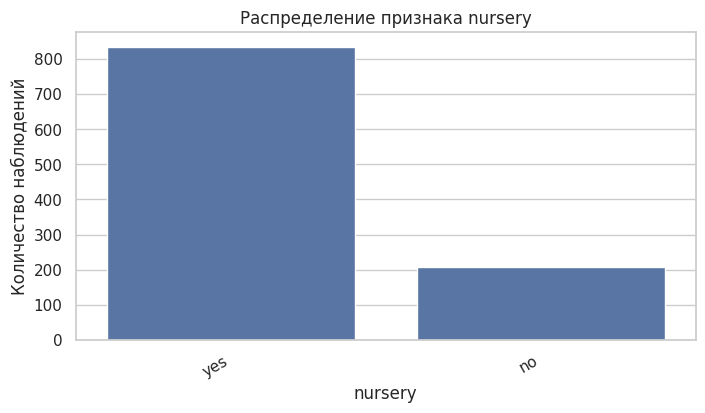

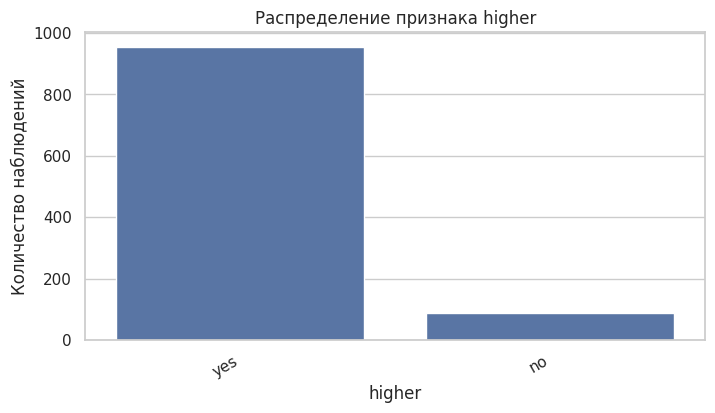

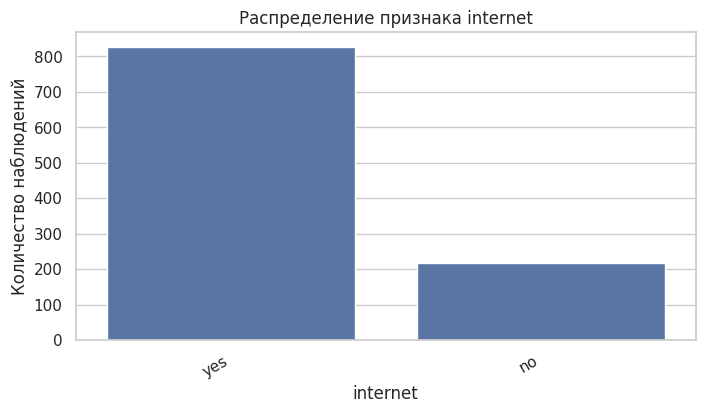

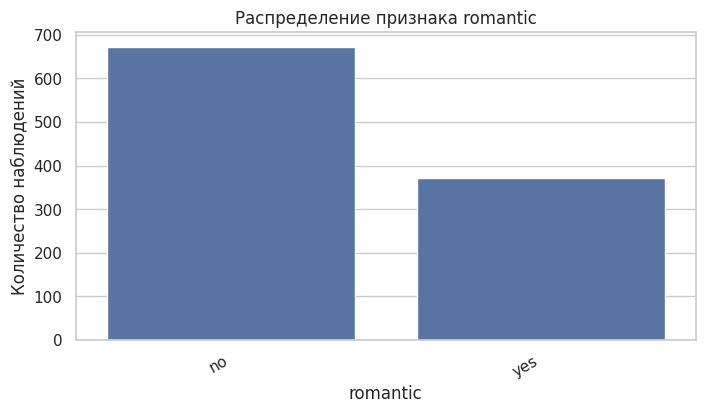

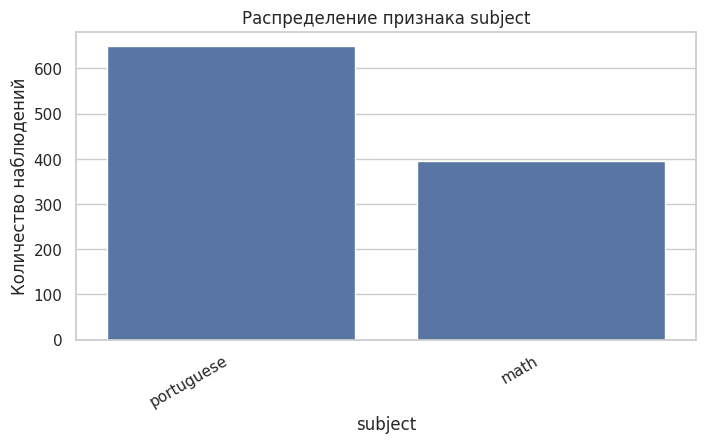

In [20]:
def plot_categorical_distribution(data, col):
    plt.figure(figsize=(8, 4))
    order = data[col].value_counts().index
    sns.countplot(data=data, x=col, order=order)
    plt.title(f"Распределение признака {col}")
    plt.xlabel(col)
    plt.ylabel("Количество наблюдений")
    plt.xticks(rotation=30, ha="right")
    plt.show()

for col in categorical_cols:
    plot_categorical_distribution(df, col)

In [21]:
def group_summary(data, group_col, target="G3"):
    return (
        data.groupby(group_col)[target]
        .agg(["count", "mean", "median", "std", "min", "max"])
        .sort_values("mean", ascending=False)
    )

# Сводная таблица средних значений G3 по всем категориальным признакам
cat_summaries = {}
for col in categorical_cols:
    cat_summaries[col] = group_summary(df, col, "G3")
    print("\n", "="*80)
    print(f"Признак: {col}")
    display(cat_summaries[col])


Признак: school


,count,mean,median,std,min,max
school,,,,,,
GP,772,11.633,12.000,3.809,0,20
MS,272,10.515,10.000,3.909,0,19



Признак: sex


,count,mean,median,std,min,max
sex,,,,,,
F,591,11.448,12.000,3.874,0,19
M,453,11.203,11.000,3.852,0,20



Признак: address


...

,count,mean,median,std,min,max
internet,,,,,,
yes,827,11.554,12.000,3.842,0,20
no,217,10.535,11.000,3.855,0,19



Признак: romantic


,count,mean,median,std,min,max
romantic,,,,,,
no,673,11.624,12.000,3.659,0,20
yes,371,10.830,11.000,4.169,0,18



Признак: subject


,count,mean,median,std,min,max
subject,,,,,,
portuguese,649,11.906,12.000,3.231,0,19
math,395,10.415,11.000,4.581,0,20


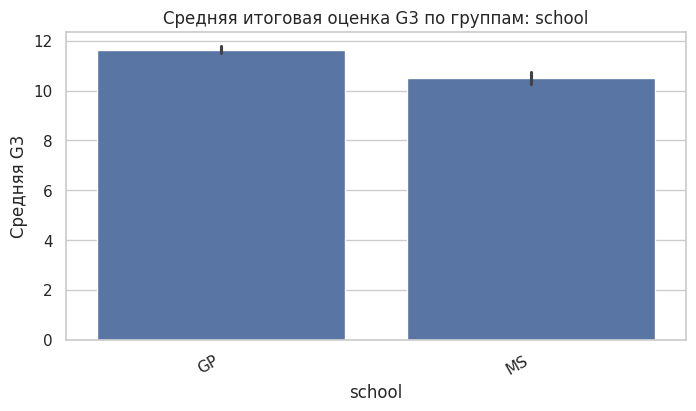

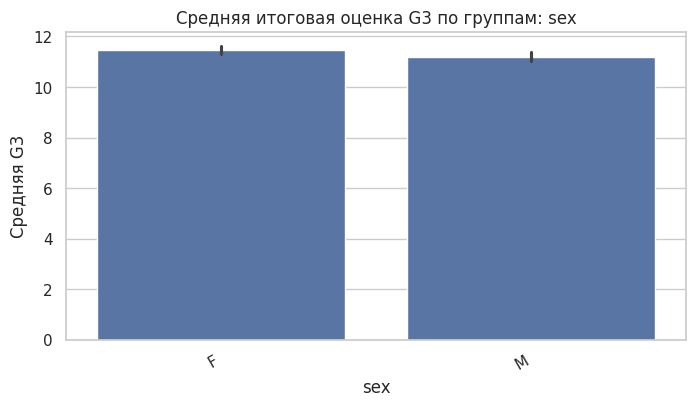

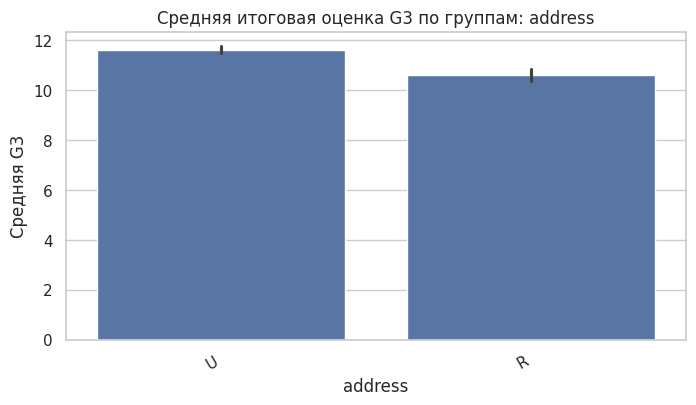

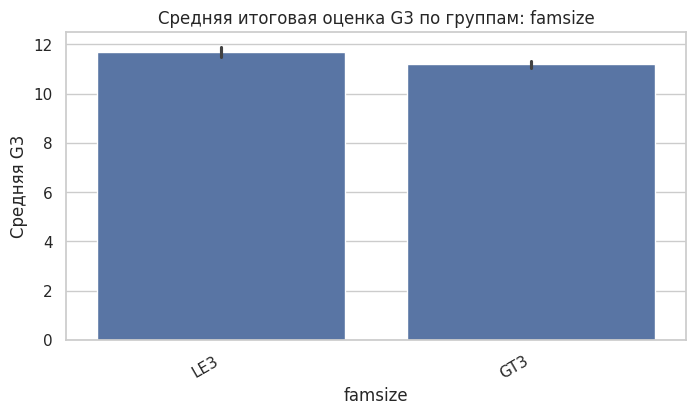

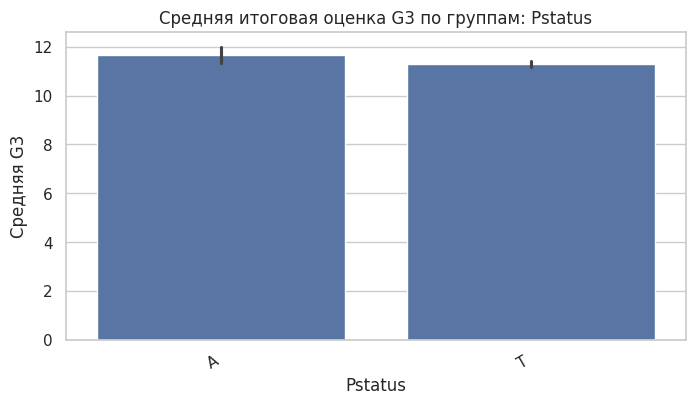

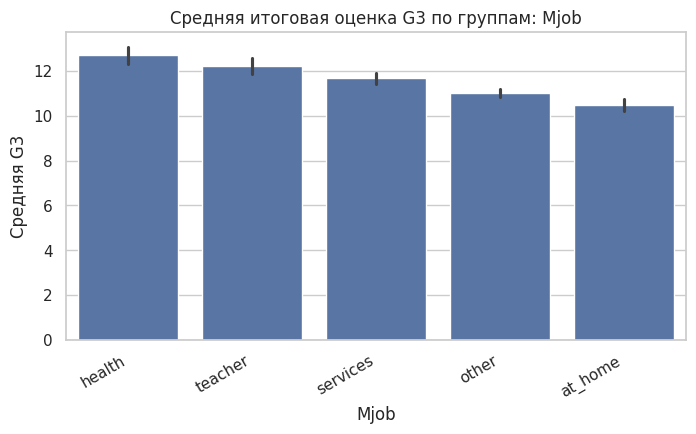

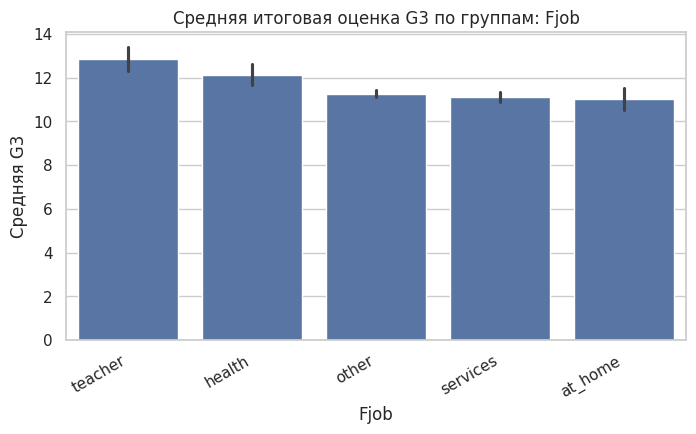

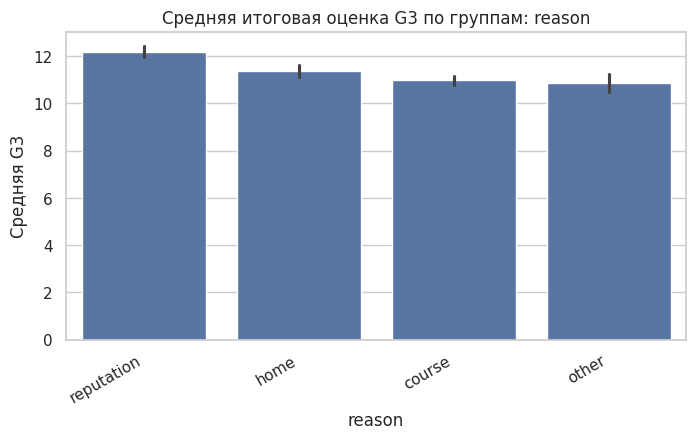

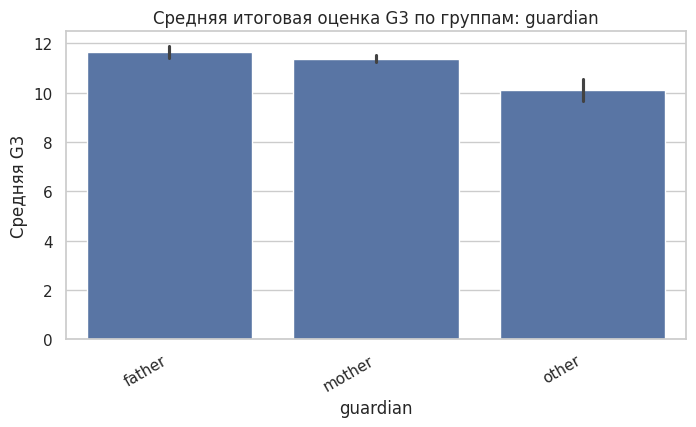

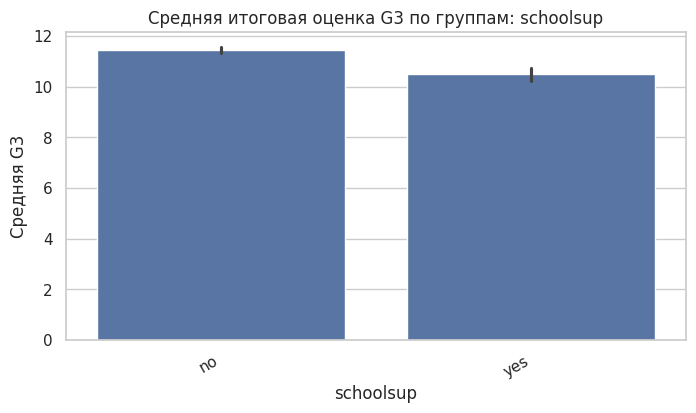

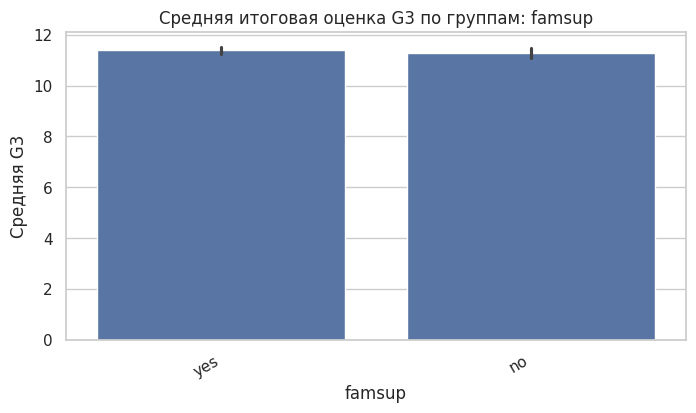

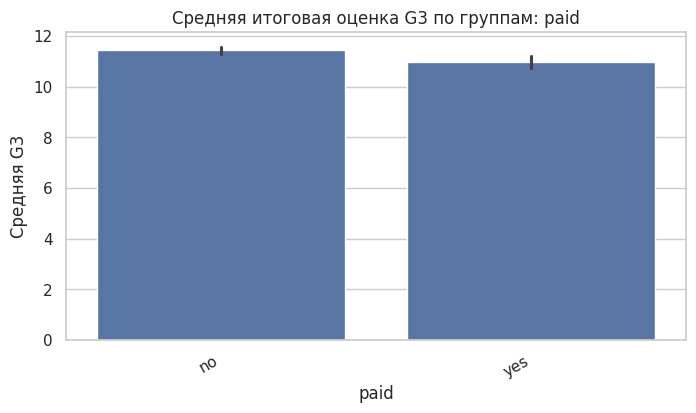

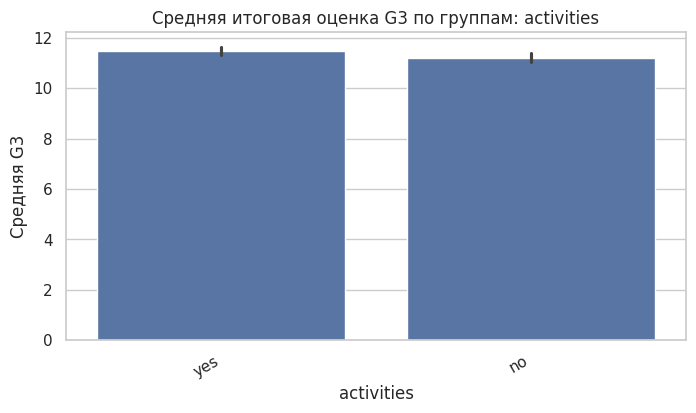

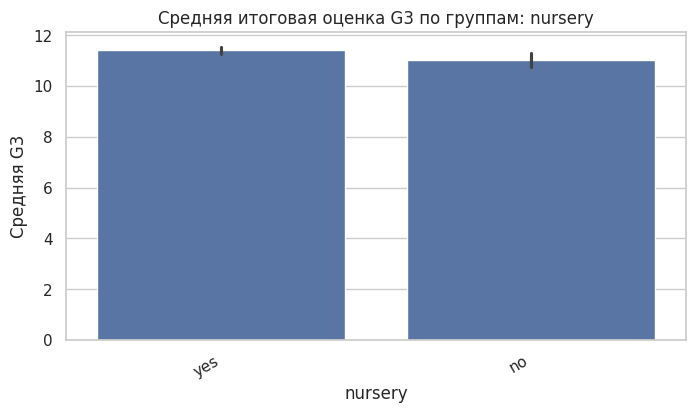

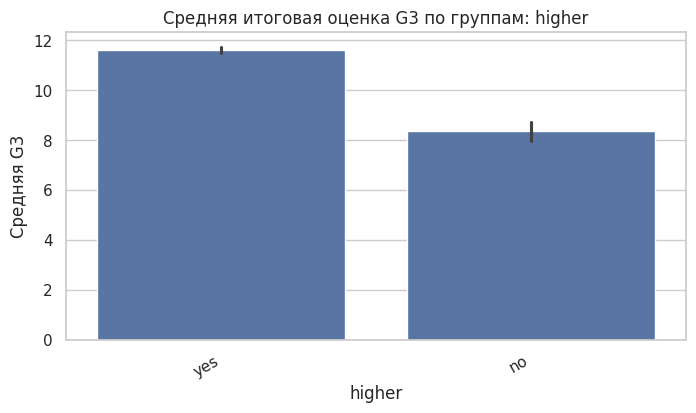

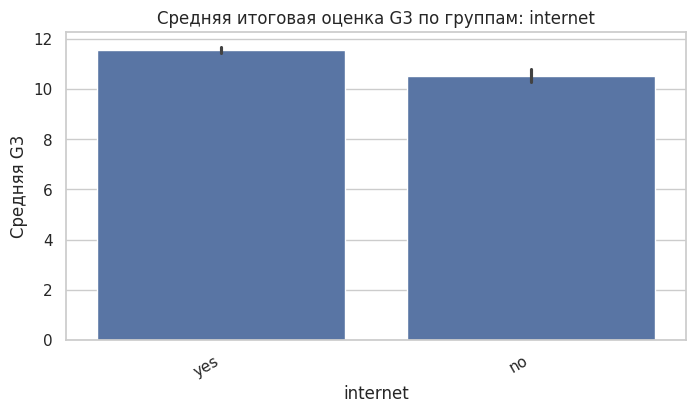

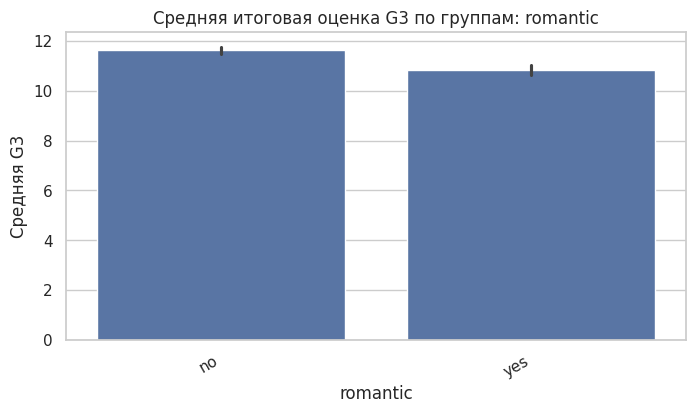

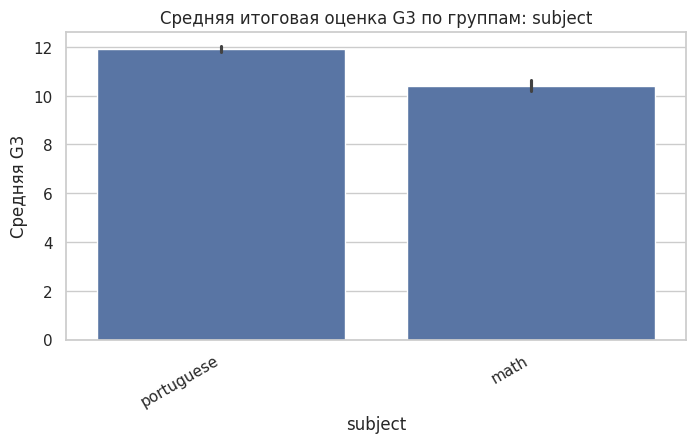

In [22]:
# Графики: средняя итоговая оценка по категориям
for col in categorical_cols:
    plt.figure(figsize=(8, 4))
    order = df.groupby(col)["G3"].mean().sort_values(ascending=False).index
    sns.barplot(data=df, x=col, y="G3", order=order, errorbar="se")
    plt.title(f"Средняя итоговая оценка G3 по группам: {col}")
    plt.xlabel(col)
    plt.ylabel("Средняя G3")
    plt.xticks(rotation=30, ha="right")
    plt.show()

## 10. Анализ числовых и порядковых признаков

Для порядковых признаков удобно смотреть среднюю итоговую оценку по значениям признака. Так можно понять, как `G3` меняется при росте `studytime`, `failures`, `goout`, `Dalc`, `Walc` и других переменных.

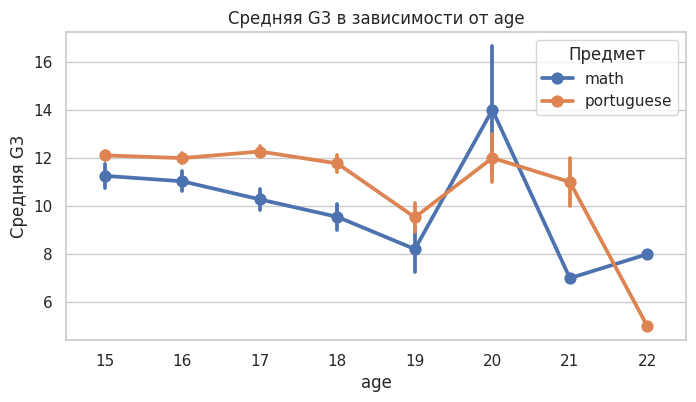

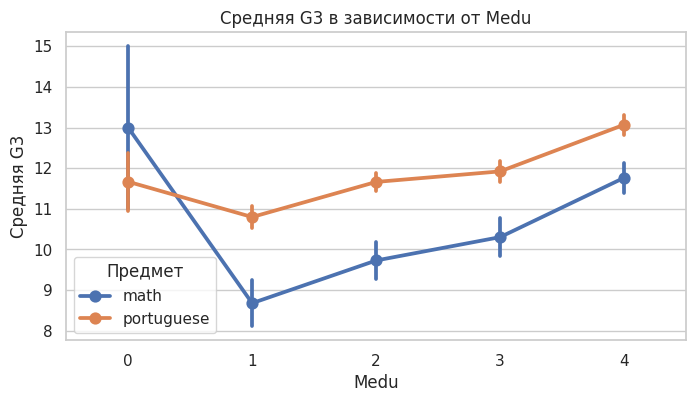

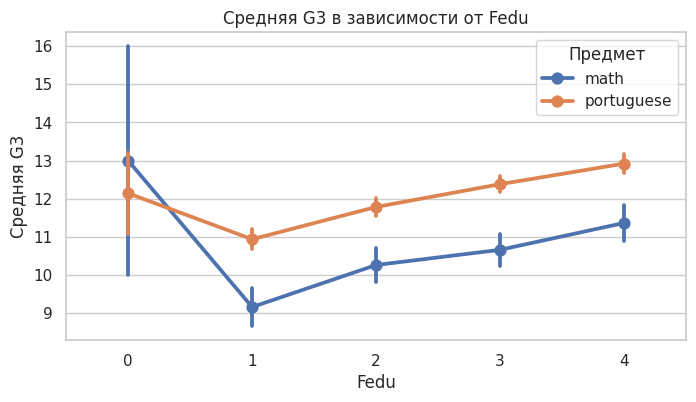

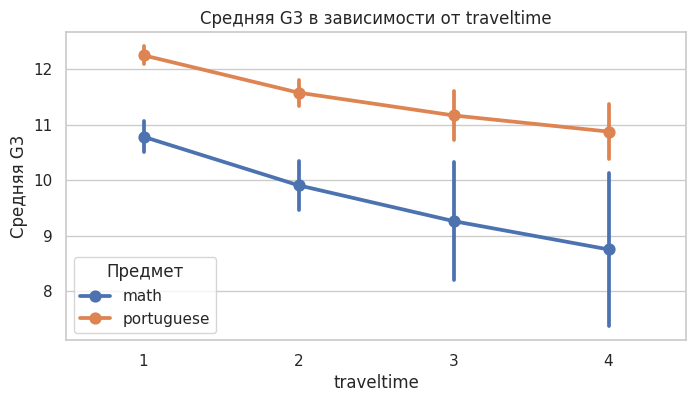

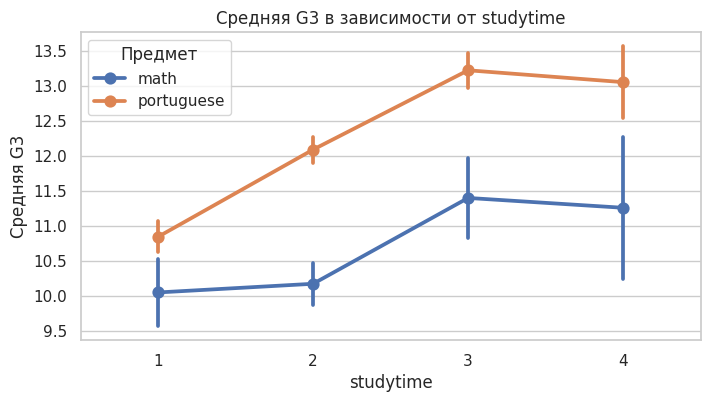

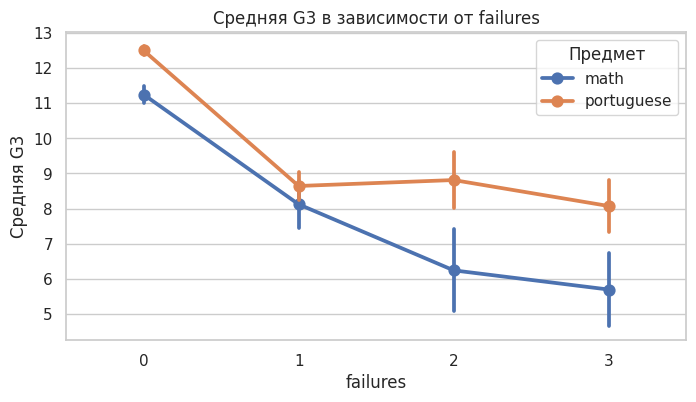

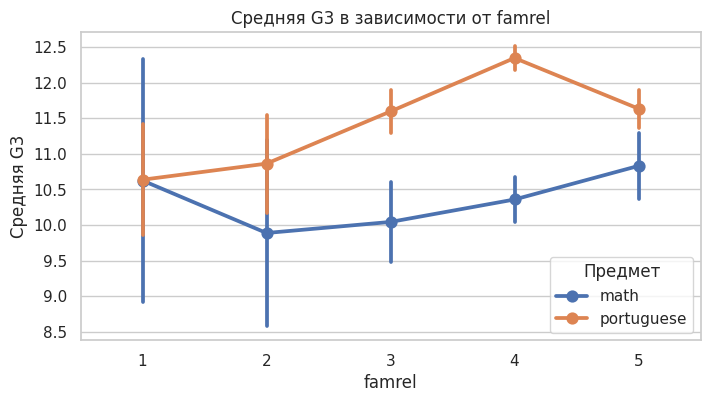

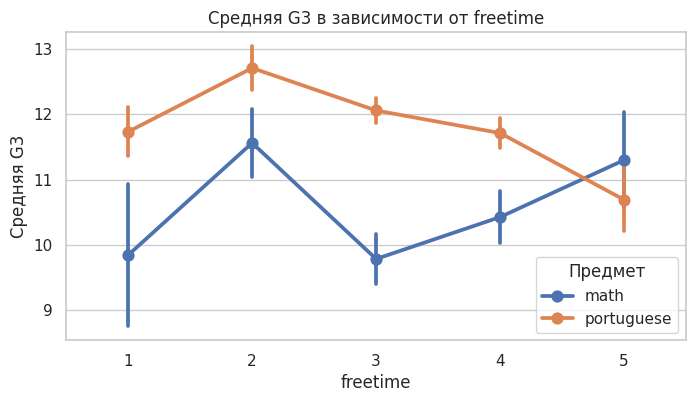

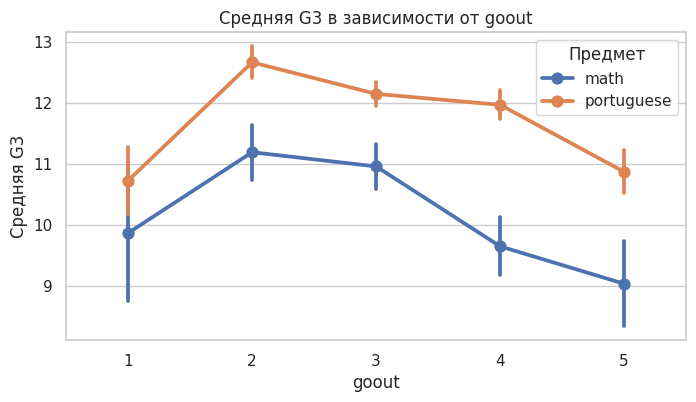

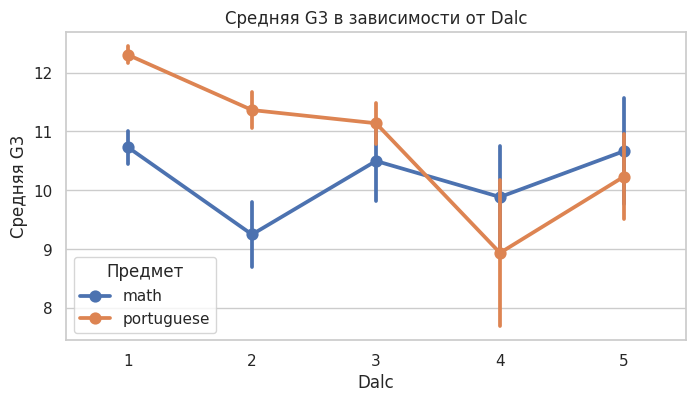

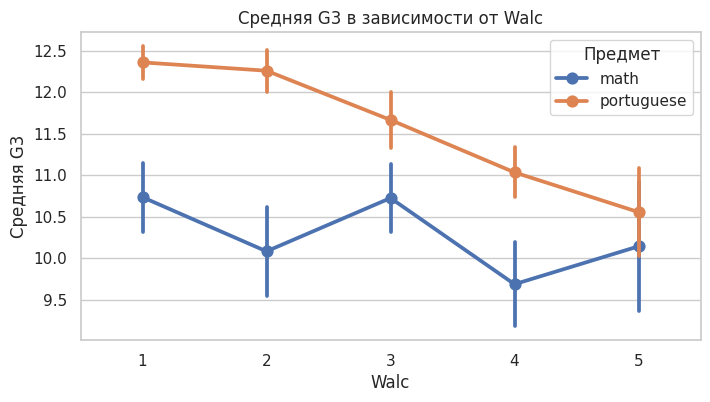

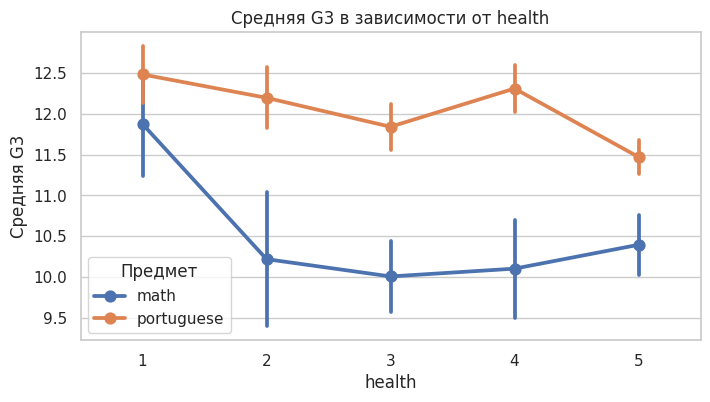

In [23]:
ordinal_like_cols = [
    "age", "Medu", "Fedu", "traveltime", "studytime", "failures",
    "famrel", "freetime", "goout", "Dalc", "Walc", "health"
]

for col in ordinal_like_cols:
    plt.figure(figsize=(8, 4))
    sns.pointplot(data=df, x=col, y="G3", hue="subject", errorbar="se")
    plt.title(f"Средняя G3 в зависимости от {col}")
    plt.xlabel(col)
    plt.ylabel("Средняя G3")
    plt.legend(title="Предмет")
    plt.show()

## 11. Пропуски занятий и итоговая оценка

`absences` — важный количественный признак. Проверим его распределение и связь с `G3`.

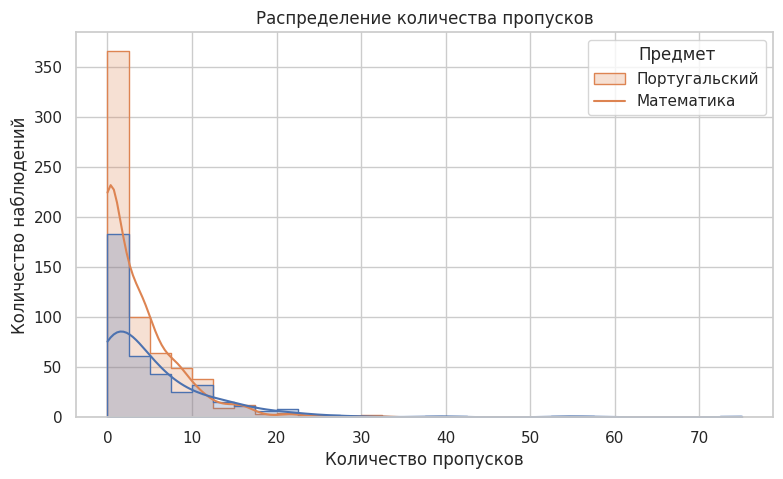

In [24]:
plt.figure(figsize=(9, 5))
sns.histplot(data=df, x="absences", hue="subject", bins=30, kde=True, element="step")
plt.title("Распределение количества пропусков")
plt.xlabel("Количество пропусков")
plt.ylabel("Количество наблюдений")
plt.legend(title="Предмет", labels=["Португальский", "Математика"])
plt.show()

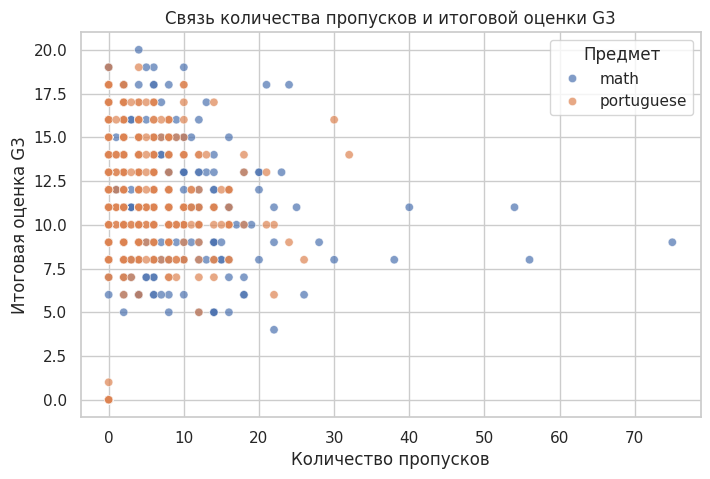

In [25]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="absences", y="G3", hue="subject", alpha=0.7)
plt.title("Связь количества пропусков и итоговой оценки G3")
plt.xlabel("Количество пропусков")
plt.ylabel("Итоговая оценка G3")
plt.legend(title="Предмет")
plt.show()

In [26]:
# Создадим группы по количеству пропусков для более наглядного сравнения
bins = [-1, 0, 5, 10, 20, df["absences"].max()]
labels = ["0", "1-5", "6-10", "11-20", "20+"]
df["absences_group"] = pd.cut(df["absences"], bins=bins, labels=labels)

absences_summary = df.groupby("absences_group", observed=True)["G3"].agg(["count", "mean", "median", "std"])
absences_summary

,count,mean,median,std
absences_group,,,,
0,359,10.889,12.000,5.236
1-5,368,11.908,11.000,2.763
6-10,202,11.673,11.000,2.903
11-20,92,10.348,10.000,2.695
20+,23,10.435,10.000,3.603


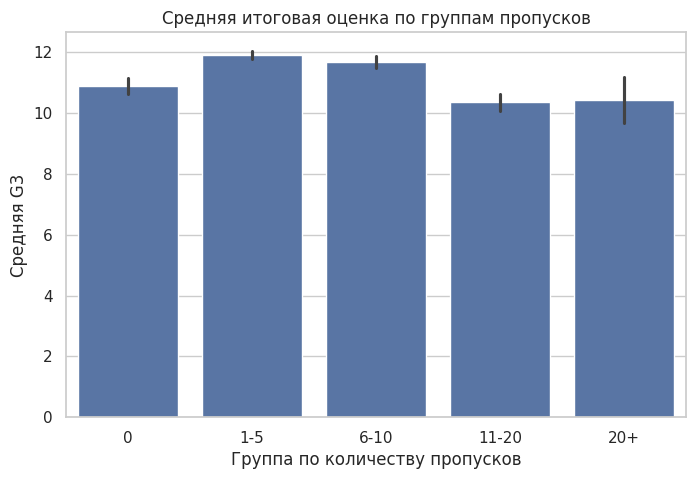

In [27]:
plt.figure(figsize=(8, 5))
sns.barplot(data=df, x="absences_group", y="G3", errorbar="se")
plt.title("Средняя итоговая оценка по группам пропусков")
plt.xlabel("Группа по количеству пропусков")
plt.ylabel("Средняя G3")
plt.show()

## 12. Прошлые академические неудачи (`failures`)

`failures` показывает число прошлых академических неудач. Этот признак потенциально очень важен: он отражает предыдущие проблемы с учебой.

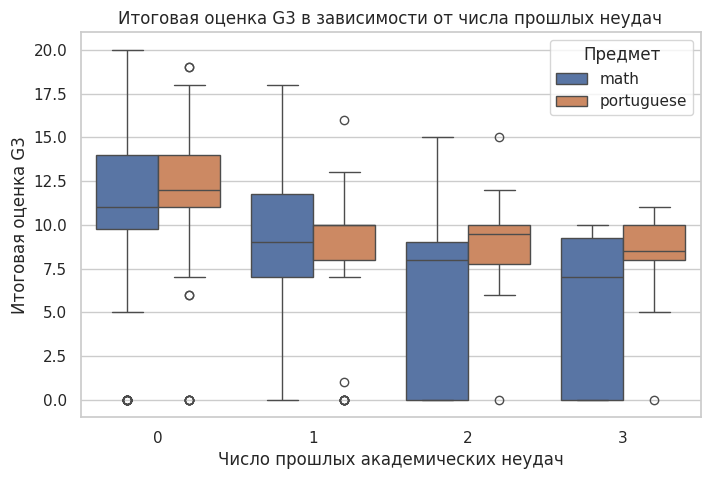

count   mean  median   std
subject    failures                            
math       0           312 11.253  11.000 4.170
           1            50  8.120   9.000 4.711
           2            17  6.235   8.000 4.842
           3            16  5.688   7.000 4.191
portuguese 0           549 12.510  12.000 2.829
           1            70  8.643  10.000 3.443
           2            16  8.812   9.500 3.209
           3            14  8.071   8.500 2.786

In [28]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="failures", y="G3", hue="subject")
plt.title("Итоговая оценка G3 в зависимости от числа прошлых неудач")
plt.xlabel("Число прошлых академических неудач")
plt.ylabel("Итоговая оценка G3")
plt.legend(title="Предмет")
plt.show()

failure_summary = df.groupby(["subject", "failures"])["G3"].agg(["count", "mean", "median", "std"])
failure_summary

## 13. Время на учебу (`studytime`)

`studytime` — порядковый признак, отражающий недельное время самостоятельной учебы. Проверим, связана ли более высокая учебная нагрузка с более высокой итоговой оценкой.

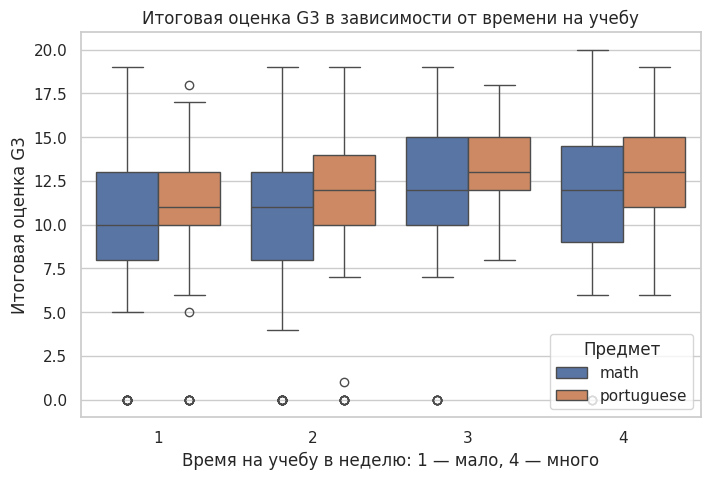

count   mean  median   std
subject    studytime                            
math       1            105 10.048  10.000 4.956
           2            198 10.172  11.000 4.218
           3             65 11.400  12.000 4.640
           4             27 11.259  12.000 5.281
portuguese 1            212 10.844  11.000 3.219
           2            305 12.092  12.000 3.243
           3             97 13.227  13.000 2.502
           4             35 13.057  13.000 3.038

In [29]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="studytime", y="G3", hue="subject")
plt.title("Итоговая оценка G3 в зависимости от времени на учебу")
plt.xlabel("Время на учебу в неделю: 1 — мало, 4 — много")
plt.ylabel("Итоговая оценка G3")
plt.legend(title="Предмет")
plt.show()

studytime_summary = df.groupby(["subject", "studytime"])["G3"].agg(["count", "mean", "median", "std"])
studytime_summary

## 14. Социальные привычки: свободное время, прогулки, алкоголь

Проверим признаки `freetime`, `goout`, `Dalc`, `Walc`. Они могут быть связаны с успеваемостью, но важно помнить: EDA показывает связь, а не причинное влияние.

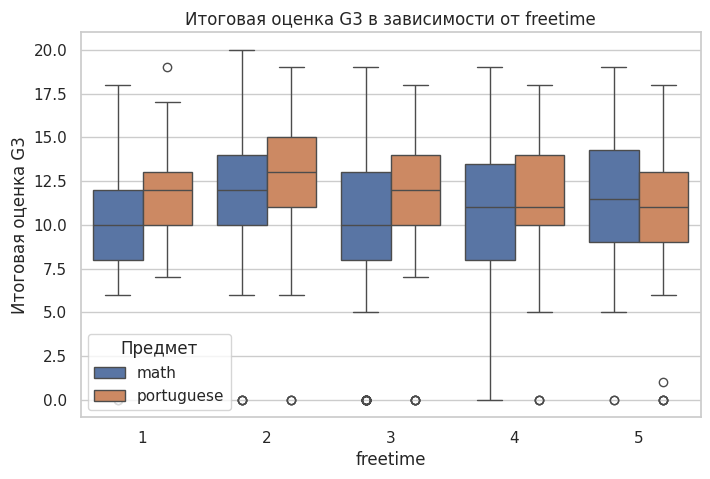

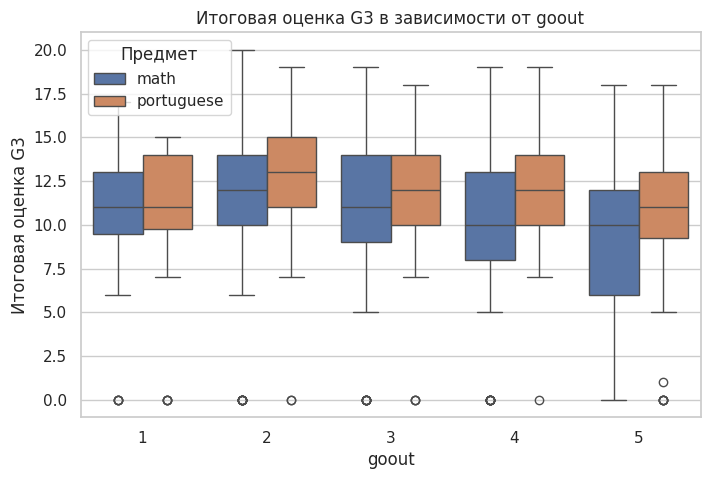

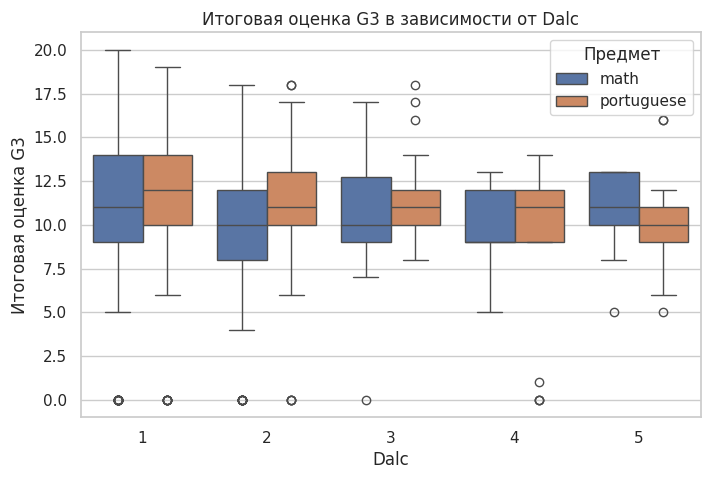

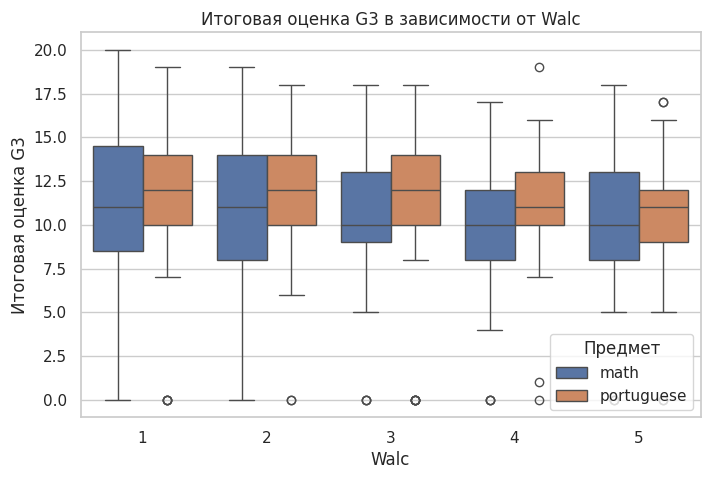

In [30]:
social_cols = ["freetime", "goout", "Dalc", "Walc"]

for col in social_cols:
    plt.figure(figsize=(8, 5))
    sns.boxplot(data=df, x=col, y="G3", hue="subject")
    plt.title(f"Итоговая оценка G3 в зависимости от {col}")
    plt.xlabel(col)
    plt.ylabel("Итоговая оценка G3")
    plt.legend(title="Предмет")
    plt.show()

## 15. Образование родителей и итоговая оценка

Признаки `Medu` и `Fedu` отражают уровень образования матери и отца. Проверим, отличаются ли средние оценки студентов при разных уровнях образования родителей.

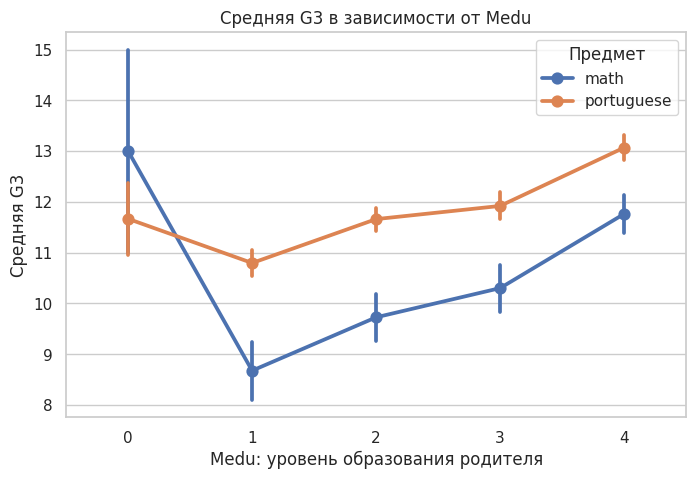

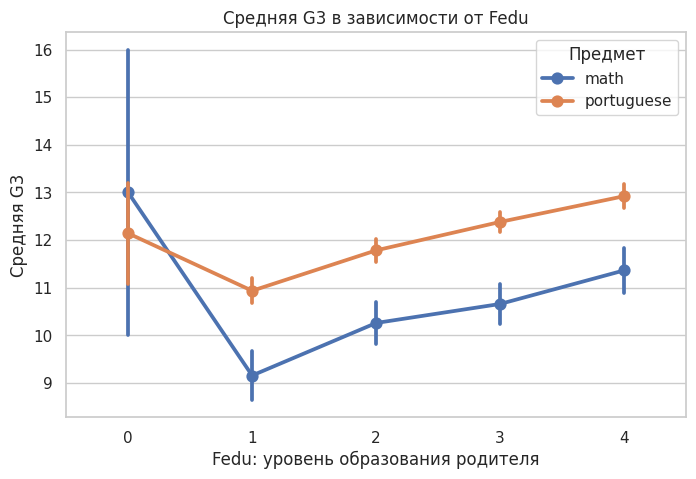

,subject,Medu,Fedu,count,mean,median
0,math,0,1,1,9.000,9.000
1,math,0,2,2,15.000,15.000
2,math,1,0,1,16.000,16.000
3,math,1,1,37,8.297,10.000
4,math,1,2,15,9.333,11.000
5,math,1,3,5,7.200,8.000
6,math,1,4,1,13.000,13.000
7,math,2,1,28,9.214,10.000
8,math,2,2,51,9.333,11.000
9,math,2,3,17,10.529,11.000


In [31]:
edu_labels = {
    0: "none",
    1: "primary",
    2: "5-9 grade",
    3: "secondary",
    4: "higher"
}

df["Medu_label"] = df["Medu"].map(edu_labels)
df["Fedu_label"] = df["Fedu"].map(edu_labels)

for col in ["Medu", "Fedu"]:
    plt.figure(figsize=(8, 5))
    sns.pointplot(data=df, x=col, y="G3", hue="subject", errorbar="se")
    plt.title(f"Средняя G3 в зависимости от {col}")
    plt.xlabel(f"{col}: уровень образования родителя")
    plt.ylabel("Средняя G3")
    plt.legend(title="Предмет")
    plt.show()

parent_edu_summary = df.groupby(["subject", "Medu", "Fedu"])["G3"].agg(["count", "mean", "median"]).reset_index()
parent_edu_summary.head(20)

## 16. Статистические тесты для групповых различий


In [33]:
def categorical_tests(data, cat_col, target="G3"):
    groups = [group[target].dropna().values for _, group in data.groupby(cat_col)]
    groups = [g for g in groups if len(g) > 1]
    n_groups = len(groups)

    result = {
        "feature": cat_col,
        "n_groups": n_groups,
        "test_1": None,
        "p_value_1": np.nan,
        "test_2": None,
        "p_value_2": np.nan
    }

    if n_groups == 2:
        t_stat, t_p = stats.ttest_ind(groups[0], groups[1], equal_var=False)
        try:
            u_stat, u_p = stats.mannwhitneyu(groups[0], groups[1], alternative="two-sided")
        except Exception:
            u_p = np.nan
        result.update({
            "test_1": "Welch t-test",
            "p_value_1": t_p,
            "test_2": "Mann-Whitney U",
            "p_value_2": u_p
        })
    elif n_groups > 2:
        f_stat, f_p = stats.f_oneway(*groups)
        try:
            h_stat, h_p = stats.kruskal(*groups)
        except Exception:
            h_p = np.nan
        result.update({
            "test_1": "ANOVA",
            "p_value_1": f_p,
            "test_2": "Kruskal-Wallis",
            "p_value_2": h_p
        })

    return result

test_results = []
for col in categorical_cols:
    test_results.append(categorical_tests(df, col, "G3"))

test_results_df = pd.DataFrame(test_results).sort_values("p_value_1")
test_results_df

,feature,n_groups,test_1,p_value_1,test_2,p_value_2
14,higher,2,Welch t-test,0.000,Mann-Whitney U,0.000
17,subject,2,Welch t-test,0.000,Mann-Whitney U,0.000
5,Mjob,5,ANOVA,0.000,Kruskal-Wallis,0.000
0,school,2,Welch t-test,0.000,Mann-Whitney U,0.000
2,address,2,Welch t-test,0.000,Mann-Whitney U,0.000
7,reason,4,ANOVA,0.001,Kruskal-Wallis,0.000
15,internet,2,Welch t-test,0.001,Mann-Whitney U,0.000
9,schoolsup,2,Welch t-test,0.001,Mann-Whitney U,0.000
16,romantic,2,Welch t-test,0.002,Mann-Whitney U,0.020
6,Fjob,5,ANOVA,0.009,Kruskal-Wallis,0.001


In [34]:
# Отдельно тесты по каждому предмету
subject_test_results = []
for subj in df["subject"].unique():
    data_subj = df[df["subject"] == subj]
    for col in categorical_cols:
        if col == "subject":
            continue
        res = categorical_tests(data_subj, col, "G3")
        res["subject"] = subj
        subject_test_results.append(res)

subject_test_results_df = pd.DataFrame(subject_test_results).sort_values(["subject", "p_value_1"])
subject_test_results_df

,feature,n_groups,test_1,p_value_1,test_2,p_value_2,subject
14,higher,2,Welch t-test,0.002,Mann-Whitney U,0.001,math
5,Mjob,5,ANOVA,0.005,Kruskal-Wallis,0.003,math
16,romantic,2,Welch t-test,0.013,Mann-Whitney U,0.070,math
9,schoolsup,2,Welch t-test,0.020,Mann-Whitney U,0.003,math
2,address,2,Welch t-test,0.037,Mann-Whitney U,0.018,math
11,paid,2,Welch t-test,0.038,Mann-Whitney U,0.227,math
1,sex,2,Welch t-test,0.040,Mann-Whitney U,0.041,math
15,internet,2,Welch t-test,0.050,Mann-Whitney U,0.032,math
3,famsize,2,Welch t-test,0.092,Mann-Whitney U,0.188,math
7,reason,4,ANOVA,0.102,Kruskal-Wallis,0.182,math


### Интерпретация статистических тестов

- Если `p-value < 0.05`, то различия между группами по `G3` статистически значимы на 5% уровне.
- Если `p-value >= 0.05`, то статистически значимых различий по этому признаку не обнаружено.


## 18. Бинарная целевая переменная для классификации

Для будущей задачи классификации можно создать переменную `pass_exam`:

\[
pass\_exam = 1, \quad если \quad G3 \geq 10
\]


In [35]:
df["pass_exam"] = (df["G3"] >= 10).astype(int)

pass_rate = df.groupby("subject")["pass_exam"].agg(["count", "mean"])
pass_rate["pass_rate_percent"] = pass_rate["mean"] * 100
pass_rate

,count,mean,pass_rate_percent
subject,,,
math,395,0.671,67.089
portuguese,649,0.846,84.592


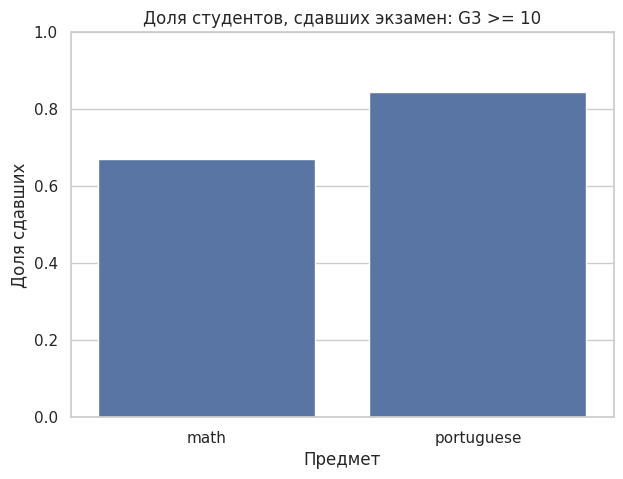

In [36]:
plt.figure(figsize=(7, 5))
sns.barplot(data=df, x="subject", y="pass_exam", errorbar=None)
plt.title("Доля студентов, сдавших экзамен: G3 >= 10")
plt.xlabel("Предмет")
plt.ylabel("Доля сдавших")
plt.ylim(0, 1)
plt.show()

## 19. Поиск потенциальных выбросов

Проверим выбросы по основным числовым переменным. Особенно важно посмотреть на `absences`, потому что количество пропусков может иметь сильную асимметрию.

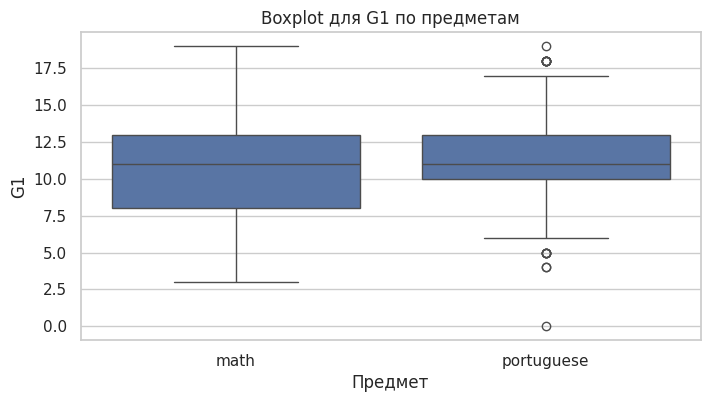

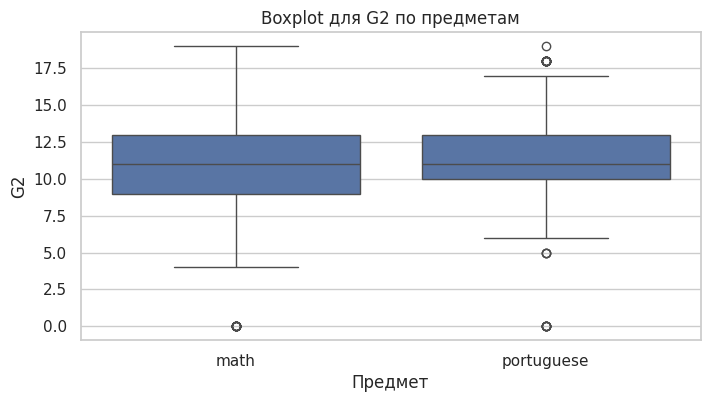

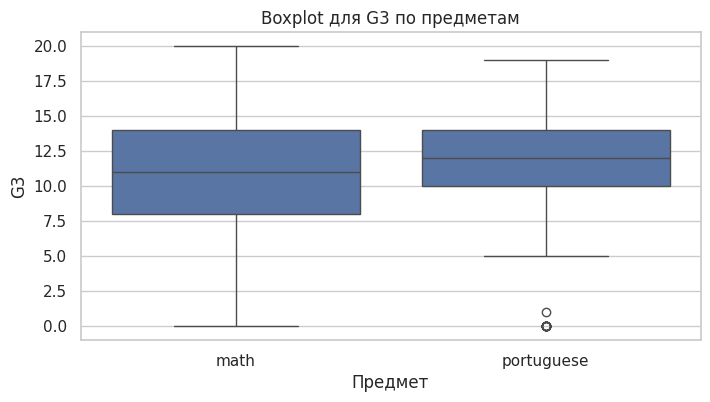

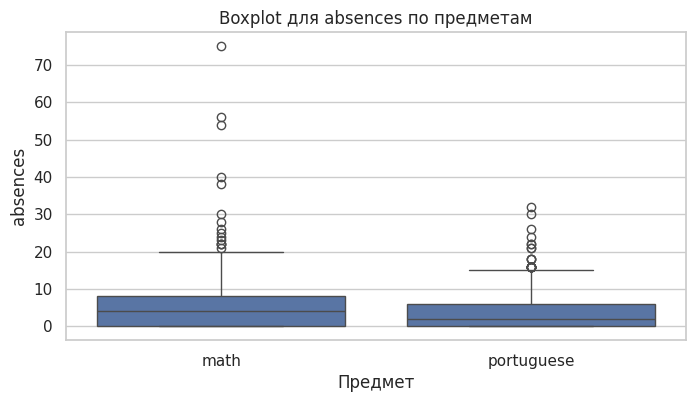

In [37]:
for col in ["G1", "G2", "G3", "absences"]:
    plt.figure(figsize=(8, 4))
    sns.boxplot(data=df, x="subject", y=col)
    plt.title(f"Boxplot для {col} по предметам")
    plt.xlabel("Предмет")
    plt.ylabel(col)
    plt.show()

In [38]:
def outlier_summary(data, cols):
    rows = []
    for col in cols:
        q1 = data[col].quantile(0.25)
        q3 = data[col].quantile(0.75)
        iqr = q3 - q1
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr
        n_outliers = ((data[col] < lower) | (data[col] > upper)).sum()
        rows.append({
            "feature": col,
            "q1": q1,
            "q3": q3,
            "iqr": iqr,
            "lower_bound": lower,
            "upper_bound": upper,
            "n_outliers": n_outliers,
            "outlier_share": n_outliers / len(data)
        })
    return pd.DataFrame(rows)

outlier_summary(df, numeric_cols)

,feature,q1,q3,iqr,lower_bound,upper_bound,n_outliers,outlier_share
0,age,16.000,18.000,2.000,13.000,21.000,2,0.002
1,Medu,2.000,4.000,2.000,-1.000,7.000,0,0.000
2,Fedu,1.000,3.000,2.000,-2.000,6.000,0,0.000
3,traveltime,1.000,2.000,1.000,-0.500,3.500,24,0.023
4,studytime,1.000,2.000,1.000,-0.500,3.500,62,0.059
5,failures,0.000,0.000,0.000,0.000,0.000,183,0.175
6,famrel,4.000,5.000,1.000,2.500,6.500,77,0.074
7,freetime,3.000,4.000,1.000,1.500,5.500,64,0.061
8,goout,2.000,4.000,2.000,-1.000,7.000,0,0.000
9,Dalc,1.000,2.000,1.000,-0.500,3.500,52,0.050


## 20. Итоговые выводы EDA

На основе проведенного анализа можно сформулировать несколько важных выводов:

1. **Датасет пригоден для анализа и моделирования.** В данных нет пропусков, признаки имеют понятную структуру, а целевая переменная `G3` задана числовой шкалой от 0 до 20.

2. **Итоговая оценка `G3` сильно связана с предыдущими оценками `G1` и `G2`.** Это логично: оценки за 1-й и 2-й периоды отражают академический уровень студента до финального результата.

3. **Признак `failures` потенциально важен для прогноза.** Чем больше прошлых академических неудач, тем ниже может быть итоговая оценка.

4. **Социально-демографические признаки тоже могут быть связаны с успеваемостью, но слабее, чем предыдущие оценки.** Например, могут отличаться средние оценки по уровню образования родителей, доступу к интернету, типу адреса, школе или желанию получить высшее образование.

5. **Для будущей регрессионной модели наиболее естественная целевая переменная — `G3`.** Ее можно предсказывать по демографическим, семейным, школьным и поведенческим признакам.

6. **Для будущей классификационной модели можно использовать переменную `pass_exam`.** Она показывает, сдал ли студент экзамен при пороге `G3 >= 10`.

7. **Нужно аккуратно относиться к признакам `G1` и `G2`.** С ними качество прогноза будет высоким, потому что они сильно коррелируют с `G3`. Без них задача сложнее, но такая модель может быть полезнее, если нужно прогнозировать итоговую оценку заранее.

## 21. Формулировка задач для дальнейшего проекта

### Задача 1. Регрессия

**Цель:** предсказать итоговую оценку студента `G3`.

**Вариант A: модель с предыдущими оценками**

- Target: `G3`
- Features: все признаки, кроме `G3`, включая `G1` и `G2`
- Смысл: максимально точный прогноз итоговой оценки на основе уже известных результатов за 1-й и 2-й периоды

**Вариант B: модель без предыдущих оценок**

- Target: `G3`
- Features: все признаки, кроме `G1`, `G2`, `G3`
- Смысл: более ранний прогноз итоговой оценки по социальным, демографическим и учебным факторам

**Модели:**

- Linear Regression
- KNN Regressor
- Random Forest Regressor

**Метрики:**

- MAE — средняя ошибка в баллах;
- RMSE — ошибка с большим штрафом за крупные промахи;
- R² — доля объясненной вариации итоговой оценки.

---

### Задача 2. Классификация

**Цель:** предсказать, сдаст ли студент экзамен.

Создаем целевую переменную:

\[
pass\_exam = 1, \quad если \quad G3 \geq 10
\]

**Модели:**

- Logistic Regression
- KNN Classifier
- Random Forest Classifier

**Метрики:**

- Accuracy — доля правильных ответов;
- Precision — точность положительных прогнозов;
- Recall — способность находить реально сдавших студентов;
- F1-score — баланс precision и recall;
- Confusion matrix — матрица ошибок классификации.